In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")


In [ ]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/krishnaik06/playstore-Dataset/main/googleplaystore.csv"
)
df.head(2)

In [ ]:
df.info()
df.shape

In [ ]:
df.describe()

In [ ]:
df.isnull().sum()  ## we have got some null values in the dataset

## Data Cleaning

In [14]:
df["Reviews"].unique()

array(['159', '967', '87510', ..., '603', '1195', '398307'],
      shape=(6002,), dtype=object)

In [15]:
df["Reviews"].str.isnumeric().sum() ## here we can see that there is one value who is not in numeric format

np.int64(10840)

In [16]:
df[~df["Reviews"].str.isnumeric()]   ## this is the row which is imposter we can see that here the reviews is with M (e.g 3.0M)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [17]:
df_copy=df.copy()  ## Made a Copy of the dataset

In [18]:
df_copy=df_copy.drop(df_copy.index[10472])   ## now we'll drop that row with the help of the index

In [19]:
df_copy[~df_copy["Reviews"].str.isnumeric()]   ## Row is removed

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [20]:
## Now we can convert the datatype into (int)
df_copy['Reviews']=df_copy['Reviews'].astype(int)

In [21]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            10840 non-null  object 
 5   Installs        10840 non-null  object 
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 1.2+ MB


In [22]:
## Size Feature
df_copy['Size'].str.isnumeric().sum()
df_copy['Size'].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

In [23]:
df_copy['Size']=df_copy['Size'].str.replace('k','')
df_copy['Size']=df_copy['Size'].str.replace('M','000')
df_copy['Size']=df_copy['Size'].replace('Varies with device',np.nan)
df_copy['Size']=df_copy['Size'].astype(float)

In [24]:
df_copy['Size']
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            9145 non-null   float64
 5   Installs        10840 non-null  object 
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(2), int64(1), object(10)
memory usage: 1.2+ MB


In [25]:
## Installs Feature
df_copy['Installs'].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0'], dtype=object)

In [26]:
df_copy[df_copy['Installs'].str.isnumeric()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
9148,Command & Conquer: Rivals,FAMILY,NaN,0,NaN,0,NaN,0,Everyone 10+,Strategy,"June 28, 2018",Varies with device,Varies with device


In [27]:
chars_to_remove=['+',',','$']
columns=['Installs','Price']

for i in chars_to_remove:
    for col in columns:
        df_copy[col]=df_copy[col].str.replace(i,'')

In [28]:
# df_copy['Installs']=df_copy['Installs'].str.replace('+','')  # WE CAN ALSO DO THIS

In [29]:
df_copy['Installs']

0           10000
1          500000
2         5000000
3        50000000
4          100000
           ...   
10836        5000
10837         100
10838        1000
10839        1000
10840    10000000
Name: Installs, Length: 10840, dtype: object

In [30]:
df_copy['Installs']=df_copy['Installs'].astype(int)
df_copy['Price']=df_copy['Price'].astype(float)

In [31]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            9145 non-null   float64
 5   Installs        10840 non-null  int64  
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  float64
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(3), int64(2), object(8)
memory usage: 1.2+ MB


In [32]:
## Last Updated Column
df_copy['Last Updated'].head(3)

0     January 7, 2018
1    January 15, 2018
2      August 1, 2018
Name: Last Updated, dtype: object

In [33]:
## First We'll update this into Date-Time using pandas
df_copy['Last Updated']=pd.to_datetime(df_copy['Last Updated'])

In [34]:
df_copy['Last Updated Date']=df_copy['Last Updated'].dt.day
df_copy['Last Updated Month']=df_copy['Last Updated'].dt.month
df_copy['Last Updated Year']=df_copy['Last Updated'].dt.year

In [ ]:
df_copy.info()

In [ ]:
df_copy.to_csv("./Datasets/Google-Play Store/Google_Play_Store_Cleaned.csv")

## EDA

In [35]:
df_copy.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Last Updated Date,Last Updated Month,Last Updated Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018


In [36]:
df_copy['App'].duplicated().sum()  ## this Dataset has duplicate records so now we'll drop the duplicates

np.int64(1181)

In [37]:
df_copy=df_copy.drop_duplicates(subset=['App'],keep='first')   # this keep will help to save the main record and this whole function will delete the duplicates records

In [38]:
df_copy['App'].duplicated().sum()  ## now we can see we have removed the Duplicates from the dataset

np.int64(0)

## Exploring Data

In [39]:
numeric_feature=[feature for feature in df_copy.columns if df_copy[feature].dtype!='O']
catogrical_feature=[feature for feature in df_copy.columns if df_copy[feature].dtype=='O']

In [36]:
print('Total Numerical Features-->',len(numeric_feature),'\n Features-->',numeric_feature)
print('Total Catogrical Features-->',len(catogrical_feature),'\n Features-->',catogrical_feature)

Total Numerical Features--> 9 
 Features--> ['Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Last Updated', 'Last Updated Date', 'Last Updated Month', 'Last Updated Year']
Total Catogrical Features--> 7 
 Features--> ['App', 'Category', 'Type', 'Content Rating', 'Genres', 'Current Ver', 'Android Ver']


## 3.2 Feature Information

1. App
   - Name of the App
2. Category
   - Category under which the App falls
3. Rating
   - Application's rating on Play Store
4. Reviews
   - Number of reviews of the App
5. Size
   - Size of the App
6. Installs
   - Number of installs of the App
7. Type
   - Whether the App is Free or Paid
8. Price
   - Price of the App (0 if it is Free
9. Content Rating
   - Appropriate target audience of the App
10. Genres
    - Genre under which the App falls
11. Last Updated
    - Date when the App was last updated
12. Current Ver
    - Current version of the application
13. Android Ver
    - Minimum Android version required to run the App

In [37]:
## Proportion of Count Data on Catogorical Columns

for col in catogrical_feature:
    print('Column Name-->',col)
    print('-------------------------------')
    print(df_copy[col].value_counts(normalize=True)*100)  ## Using Normalize=True it help to get the data in %agr
    print('-------------------------------')

Column Name--> App
-------------------------------
App
Photo Editor & Candy Camera & Grid & ScrapBook        0.010353
Coloring book moana                                   0.010353
U Launcher Lite – FREE Live Cool Themes, Hide Apps    0.010353
Sketch - Draw & Paint                                 0.010353
Pixel Draw - Number Art Coloring Book                 0.010353
                                                        ...   
Sya9a Maroc - FR                                      0.010353
Fr. Mike Schmitz Audio Teachings                      0.010353
Parkinson Exercices FR                                0.010353
The SCP Foundation DB fr nn5n                         0.010353
iHoroscope - 2018 Daily Horoscope & Astrology         0.010353
Name: proportion, Length: 9659, dtype: float64
-------------------------------
Column Name--> Category
-------------------------------
Category
FAMILY                 18.966767
GAME                    9.928564
TOOLS                   8.561963
BUSINESS 

df_copy

## Visualization

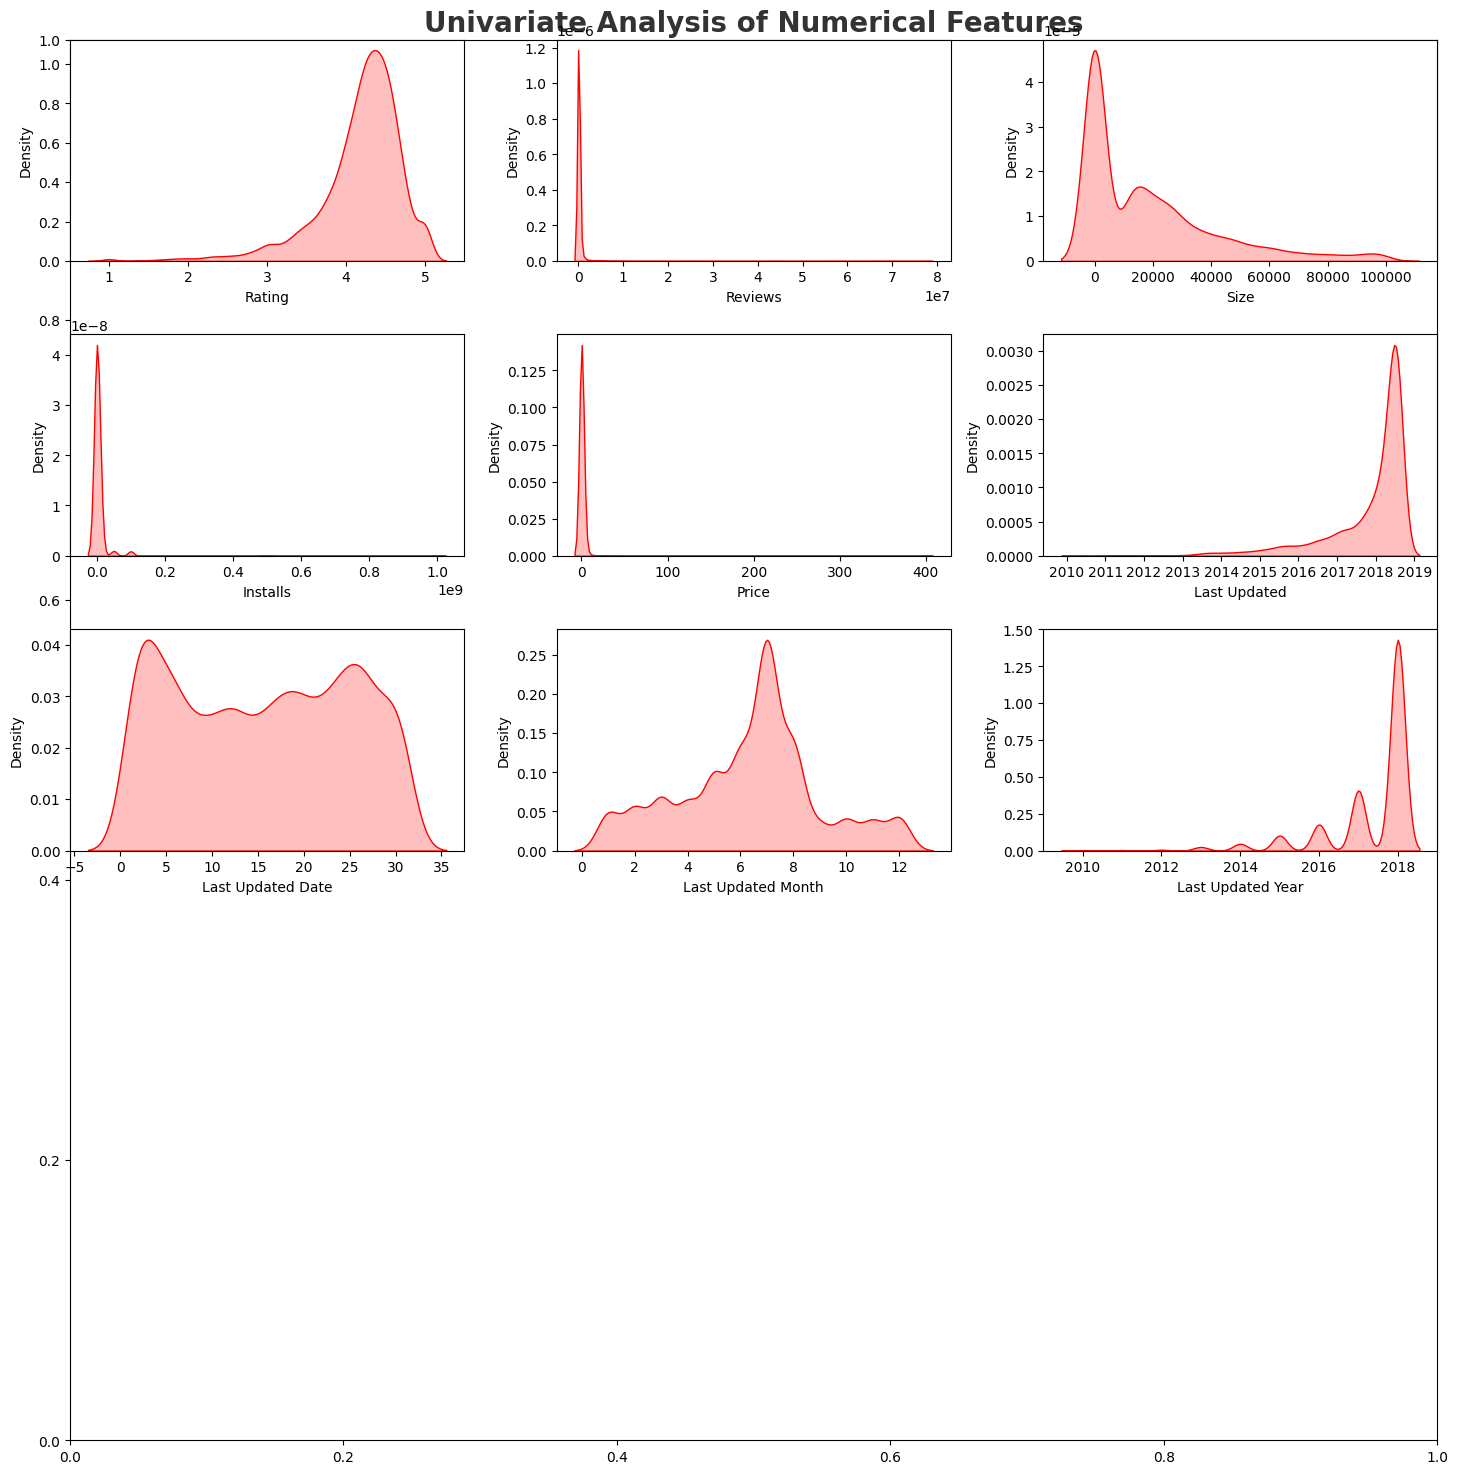

In [38]:
plt.figure(figsize=(15,15))
plt.title('Univariate Analysis of Numerical Features',fontsize=20,fontweight='bold',alpha=0.8,y=1.)

for i in range(0,len(numeric_feature)):
    plt.subplot(5,3,i+1)
    sns.kdeplot(x=df_copy[numeric_feature[i]],shade=True,color='r')
    plt.xlabel(numeric_feature[i])
    plt.tight_layout()

## Observation
Rating and Year are left and Reviews ,Size , Installs and Price are right Skewed

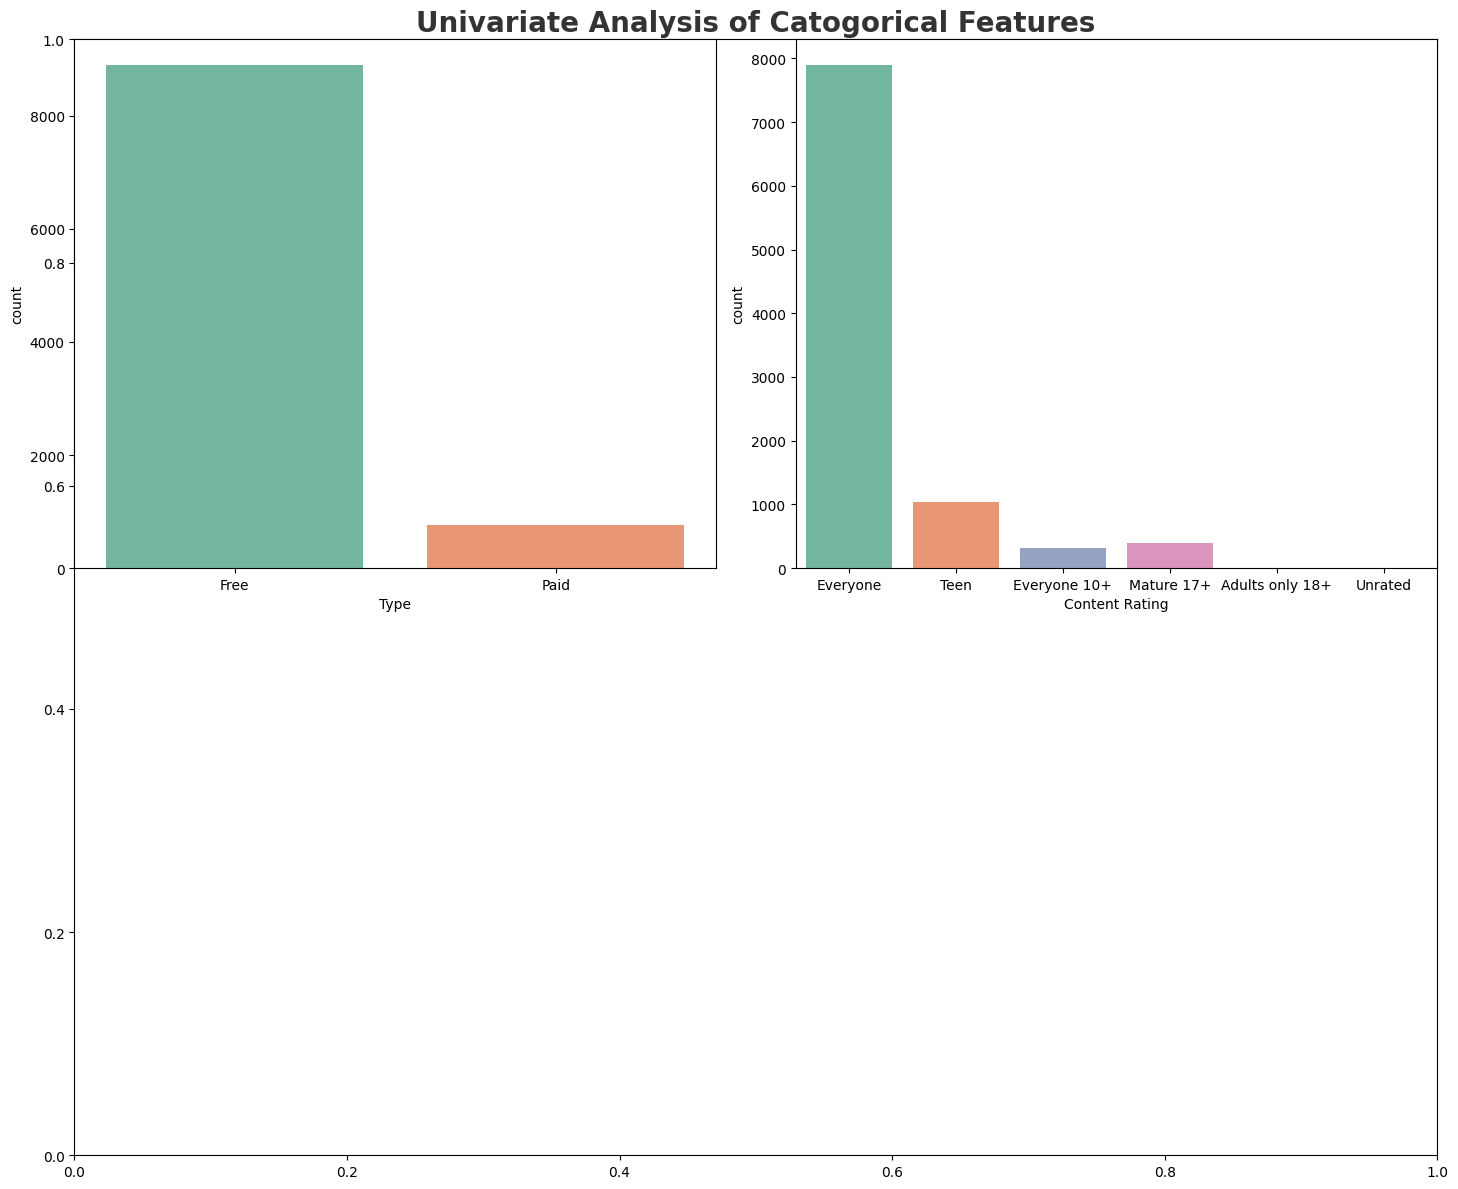

In [39]:
## Catogorical Features
plt.figure(figsize=(15,12))
plt.title('Univariate Analysis of Catogorical Features',fontsize=20,fontweight='bold',alpha=0.8,y=1.)
category=['Type','Content Rating']
for i in range(0,len(category)):
    plt.subplot(2,2,i+1)
    sns.countplot(x=df_copy[category[i]],palette='Set2')
    plt.xlabel(category[i])
    # plt.yticks(rotation=45)
    plt.tight_layout()

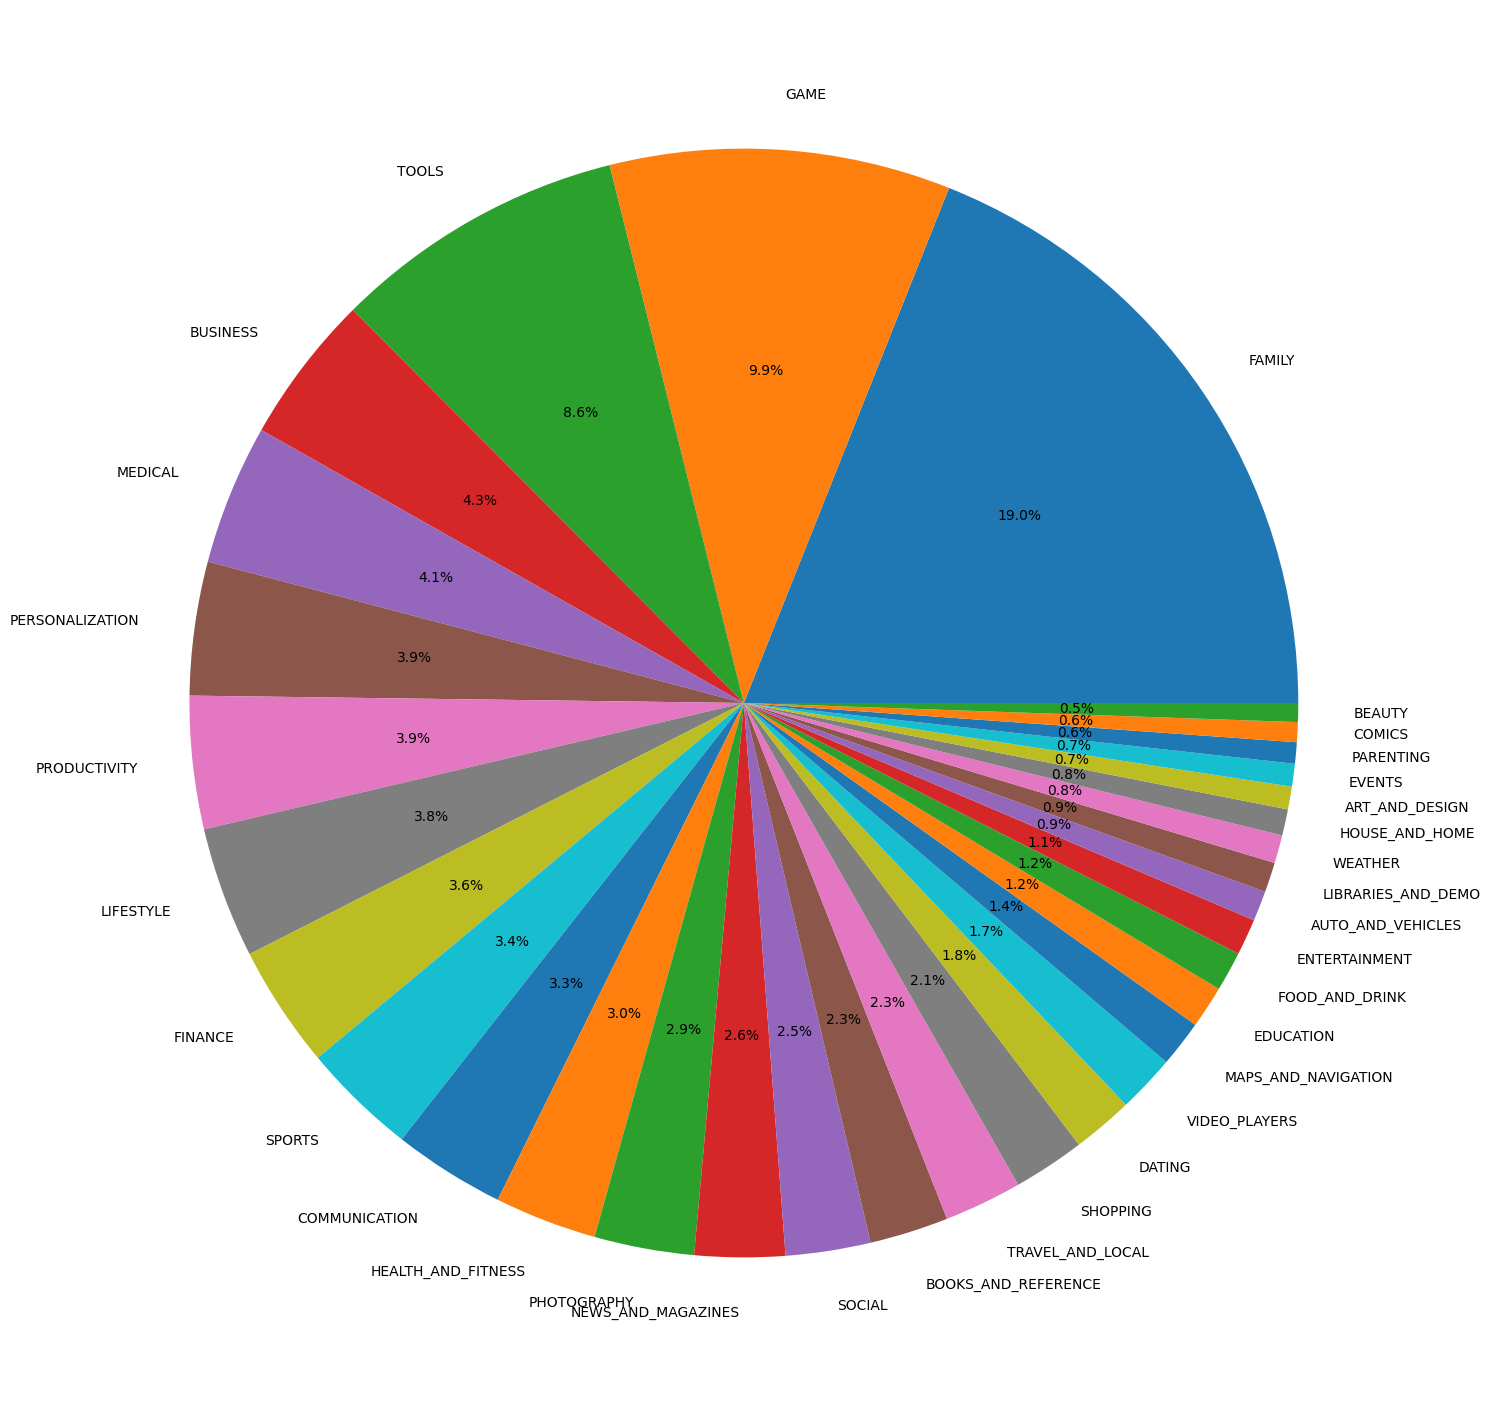

In [40]:
plt.figure(figsize=(18,18))
df_copy['Category'].value_counts().plot.pie(y=df_copy['Category'],autopct='%1.1f%%')
plt.ylabel('')
plt.show()

## Observation

1. Family, Games, and Tools are the most popular app categories on the Google Play Store, having the highest number of applications.
2. Beauty, Comics, Arts, and Weather categories have the lowest number of applications on the Google Play Store.

In [50]:
df_copy.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Last Updated Date,Last Updated Month,Last Updated Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018


In [53]:
## Top 10 App Catogories
category=pd.DataFrame(df['Category'].value_counts())
category.rename(columns={'Category':'Count'},inplace=True)

In [54]:
category

,count
Category,
FAMILY,1972
GAME,1144
TOOLS,843
MEDICAL,463
BUSINESS,460
PRODUCTIVITY,424
PERSONALIZATION,392
COMMUNICATION,387
SPORTS,384


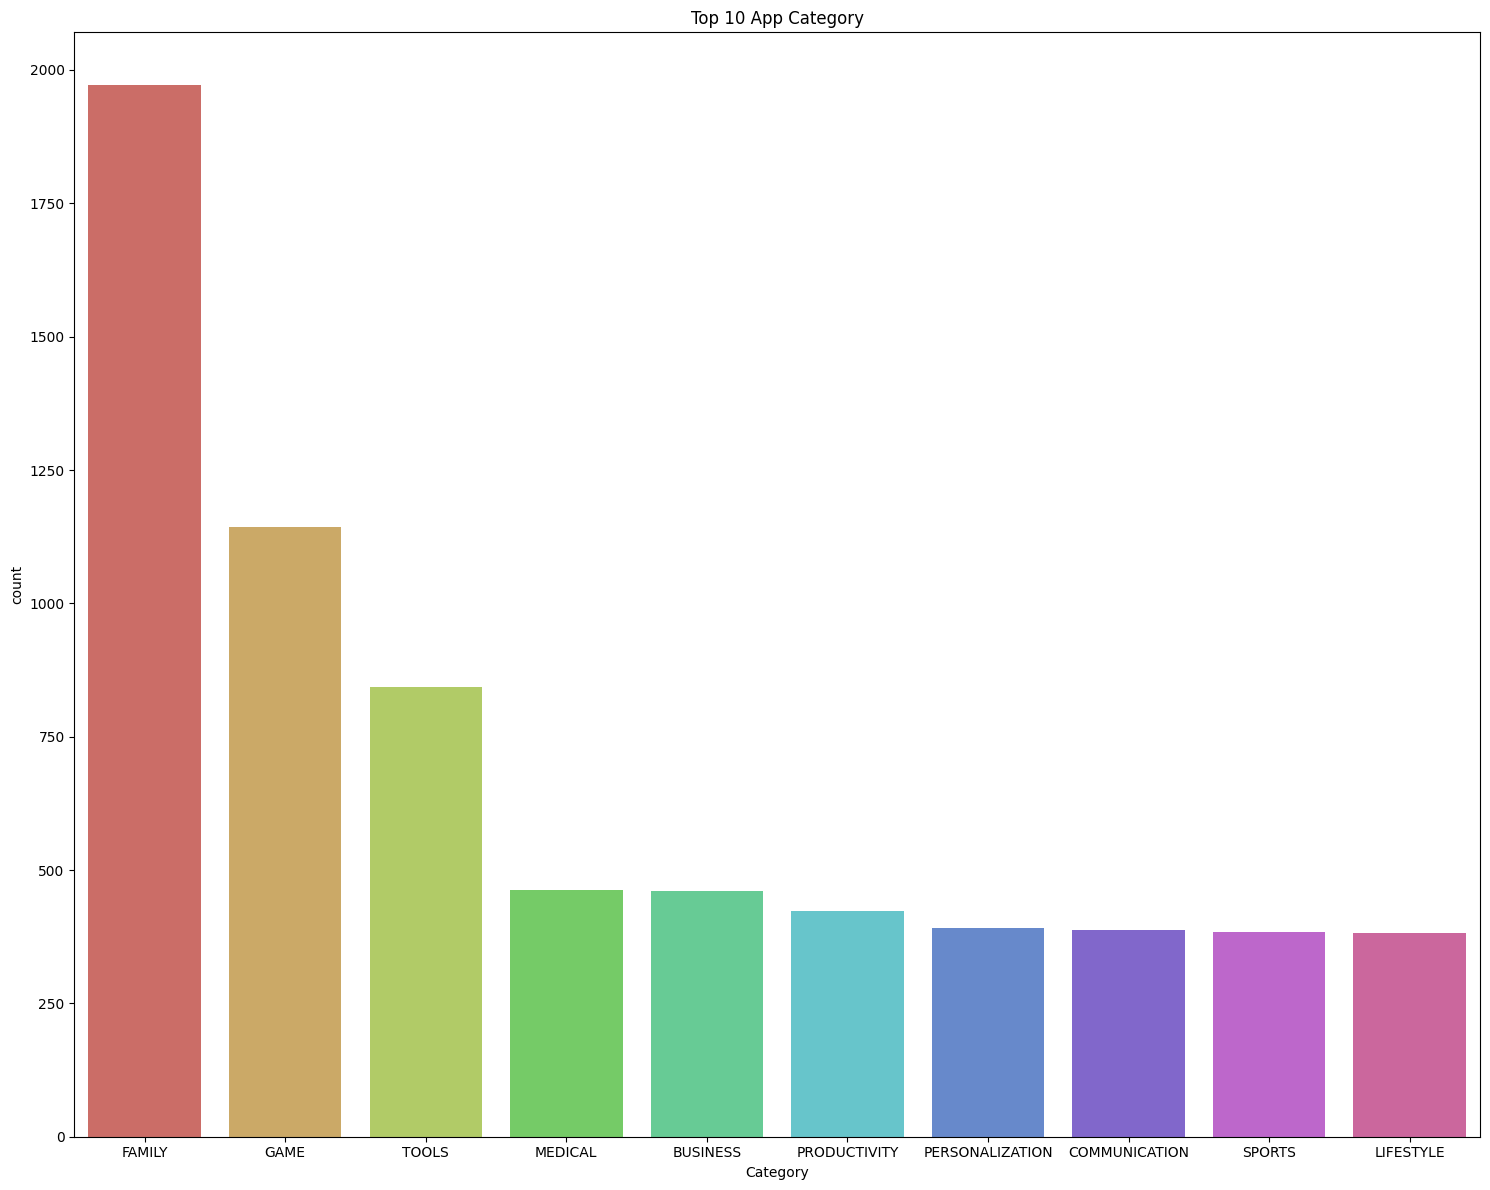

In [66]:
plt.figure(figsize=(15,12))
plt.title('Top 10 App Category')
sns.barplot(x=category.index[:10],y='count',data=category[:10],palette='hls')
plt.tight_layout()
plt.show()

## Insights
1. Family category has the most number of apps with 18% of apps belonging to it, followed by Games category which has 11% of the apps.
2. Least number of apps belong to the Beauty category with less than 1% of the total apps belonging to it.

## Which Category has largest Number of Installation

In [117]:
df_copy.sort_values(by='Installs',ascending=False)[:1]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Last Updated Date,Last Updated Month,Last Updated Year
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53000.0,1000000000,Free,0.0,Everyone,Education,2017-07-25,1.48,4.1 and up,25,7,2017


In [ ]:
df_copy.head()

In [120]:
# Which Category has largest Number of Installation
df_copy.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(1)

Category
FAMILY    17158175000
Name: Installs, dtype: int64

## What are the top 5 most Installed Apps in Each Popular Categories?

In [143]:
top_5_apps = df_copy.groupby('Category').apply(
    lambda x: x.sort_values('Installs', ascending=False).head(5)
)

top_5_apps[['App', 'Category', 'Installs']]

App  \
Category                                                                  
ART_AND_DESIGN 8888             Spring flowers theme couleurs d t space   
               8871                              Test Application DT 02   
               8712              Name Art DP - Focus n Filter Text 2018   
               8679                                        Dp for girls   
               7174                             Easy DIY CD Craft Ideas   
...                                                                 ...   
WEATHER        10832                                           FR Tides   
               10612                  Clearwater, FL - weather and more   
               10625              St. Petersburg, FL - weather and more   
               10627          WSVN • South Florida's Source for Weather   
               10713  My Earthquake Alerts - US & Worldwide Earthquakes   

                            Category    Installs  
Category                                          
ART_AND_DESIGN 8888   ART_AND_DESIGN     5000000  
               8871   ART_AND_DESIGN     5000000  
               8712   ART_AND_DESIGN     1000000  
               8679   ART_AND_DESIGN     1000000  
               7174   ART_AND_DESIGN      500000  
...                              ...         ...  
WEATHER        10832         WEATHER  1000000000  
               10612         WEATHER   100000000  
               10625         WEATHER   100000000  
               10627         WEATHER   100000000  
               10713         WEATHER   100000000  

[165 rows x 3 columns]

In [153]:
df_copy.groupby('Category').apply(
    lambda x: x.sort_values('Installs', ascending=False).head(5)
)[['App','Installs']]


App  \
Category                                                                  
ART_AND_DESIGN 8888             Spring flowers theme couleurs d t space   
               8871                              Test Application DT 02   
               8712              Name Art DP - Focus n Filter Text 2018   
               8679                                        Dp for girls   
               7174                             Easy DIY CD Craft Ideas   
...                                                                 ...   
WEATHER        10832                                           FR Tides   
               10612                  Clearwater, FL - weather and more   
               10625              St. Petersburg, FL - weather and more   
               10627          WSVN • South Florida's Source for Weather   
               10713  My Earthquake Alerts - US & Worldwide Earthquakes   

                        Installs  
Category                          
ART_AND_DESIGN 8888      5000000  
               8871      5000000  
               8712      1000000  
               8679      1000000  
               7174       500000  
...                          ...  
WEATHER        10832  1000000000  
               10612   100000000  
               10625   100000000  
               10627   100000000  
               10713   100000000  

[165 rows x 2 columns]

## How many Apps are there on Google Play Store which get 5 rating

In [173]:
print('Total:',df_copy[df_copy['Rating']==5][['App']].shape[0])
df_copy[df_copy['Rating']==5][['App']]

Total: 271


,App
329,Hojiboy Tojiboyev Life Hacks
612,American Girls Mobile Numbers
615,Awake Dating
633,Spine- The dating app
636,Girls Live Talk - Free Text and Video Chat
...,...
10721,Mad Dash Fo' Cash
10742,GKPB FP Online Church
10776,Monster Ride Pro
10820,Fr. Daoud Lamei
